<a href="https://colab.research.google.com/github/GaganaGB/Machinelearninglab/blob/main/experiment6(online_retail).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Dataset Shape:
(541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Missing Valu

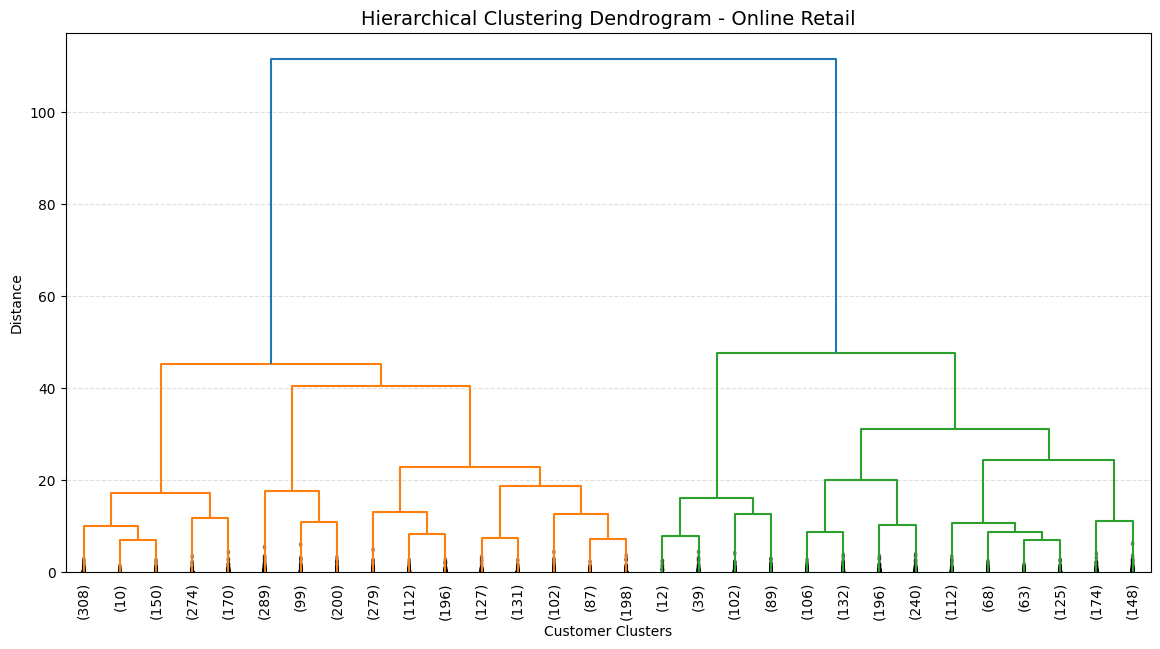

Number of clusters = 2, Silhouette Score = 0.4092
Number of clusters = 3, Silhouette Score = 0.3526
Number of clusters = 4, Silhouette Score = 0.2419
Number of clusters = 5, Silhouette Score = 0.2596
Number of clusters = 6, Silhouette Score = 0.2462
Number of clusters = 7, Silhouette Score = 0.2434
Number of clusters = 8, Silhouette Score = 0.2157
Number of clusters = 9, Silhouette Score = 0.2174
Number of clusters = 10, Silhouette Score = 0.2233


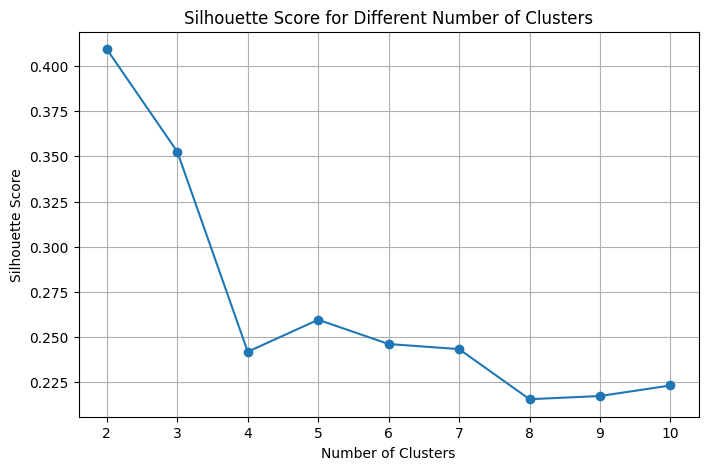


Number of clusters selected: 3
Suggested dendrogram cut-off distance: 46.389


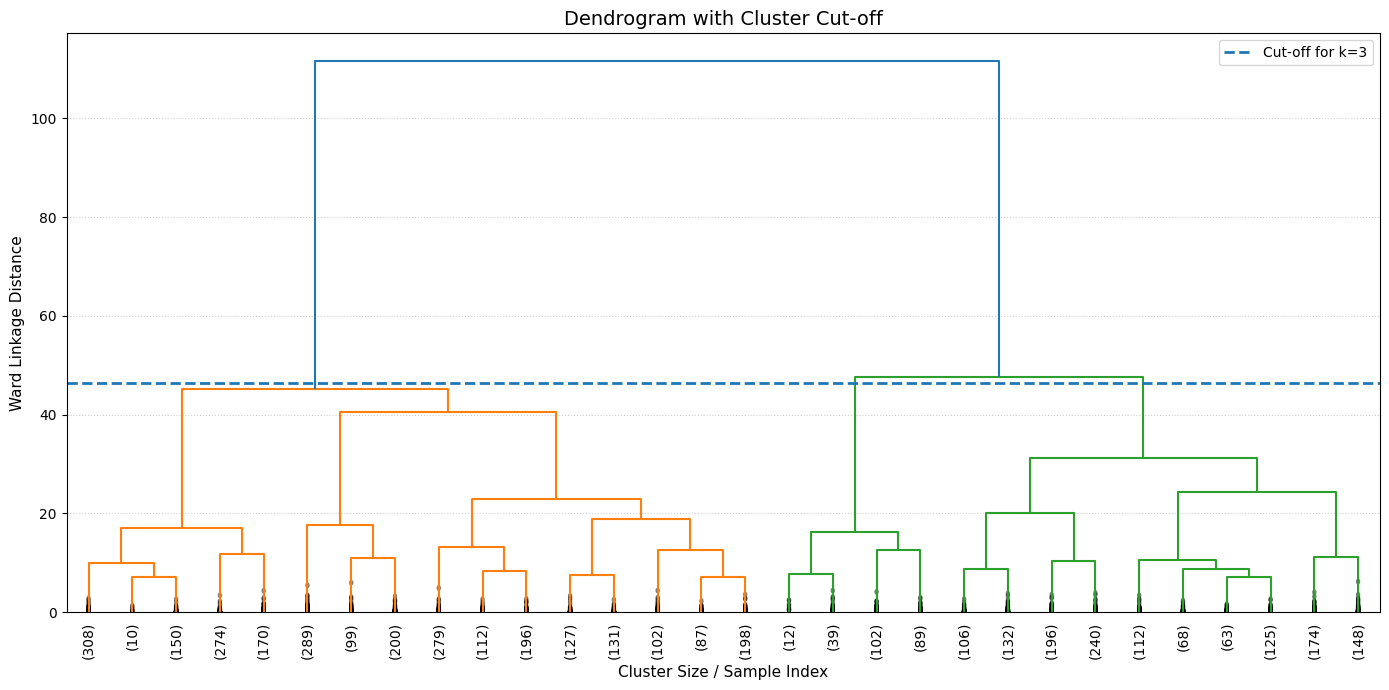


Customer Cluster Assignments:
    CustomerID  Recency  Frequency  Monetary  Cluster
0      12346.0      326          1  77183.60        1
1      12347.0        2          7   4310.00        3
2      12348.0       75          4   1797.24        1
3      12349.0       19          1   1757.55        3
4      12350.0      310          1    334.40        1
5      12352.0       36          8   2506.04        3
6      12353.0      204          1     89.00        1
7      12354.0      232          1   1079.40        1
8      12355.0      214          1    459.40        1
9      12356.0       23          3   2811.43        3
10     12357.0       33          1   6207.67        1
11     12358.0        2          2   1168.06        3
12     12359.0       58          4   6372.58        3
13     12360.0       52          3   2662.06        3
14     12361.0      287          1    189.90        1
15     12362.0        3         10   5226.23        3
16     12363.0      110          2    552.00       

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("\nData after preprocessing:")
print(df.head())


df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
        "InvoiceNo": "nunique",
            "TotalAmount": "sum"
            })

rfm.columns = ["Recency", "Frequency", "Monetary"]


print("\nRFM Dataset:")
print(rfm.head())

print("\nRFM Shape:")
print(rfm.shape)

print("\nMissing values in RFM:")
print(rfm.isnull().sum())

features = [
      'Recency',
          'Frequency',
              'Monetary'
              ]

X = rfm[features]

sup = StandardScaler()

X_scaled = sup.fit_transform(X)

print("\nStandardized RFM Data:")
print(X_scaled[:5])

rfm_log = np.log1p(rfm)


rfm_scaled = sup.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
        columns=rfm.columns,
            index=rfm.index
            )

print("\nScaled RFM data:")
print(rfm_scaled.head())

linked = linkage(
      rfm_scaled,
          method="ward"
          )


plt.figure(figsize=(14, 7))

dendrogram(
    linked,
        truncate_mode="lastp",
            p=30,
                leaf_rotation=90,
                    leaf_font_size=10,
                        show_contracted=True
                        )

plt.title("Hierarchical Clustering Dendrogram - Online Retail",fontsize=14)

plt.xlabel("Customer Clusters")
plt.ylabel("Distance")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

silhouette_scores = []

for k in range(2, 11):

    labels = fcluster(
            linked,
                    t=k,
                            criterion="maxclust"
                                )

    score = silhouette_score(rfm_scaled,labels)

    silhouette_scores.append(score)

    print(f"Number of clusters = {k}, "f"Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
        silhouette_scores,
            marker="o"
            )

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score for Different Number of Clusters")

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

optimal_k = 3

# Number of customers
n = len(rfm)

# Calculate suitable cut-off distance
lower_distance = linked[n - optimal_k - 1, 2]
upper_distance = linked[n - optimal_k, 2]

cutoff_distance = (
    lower_distance + upper_distance
    ) / 2

print("\nNumber of clusters selected:", optimal_k)

print("Suggested dendrogram cut-off distance:",round(cutoff_distance, 3))

plt.figure(figsize=(14, 7))

dendrogram(
    linked,
        truncate_mode='lastp',
            p=30,
                leaf_rotation=90,
                    leaf_font_size=10,
                        show_contracted=True
                        )

plt.axhline(y=cutoff_distance,linestyle='--',linewidth=2,label=f'Cut-off for k={optimal_k}')

plt.title('Dendrogram with Cluster Cut-off',fontsize=14)

plt.xlabel('Cluster Size / Sample Index',fontsize=11)

plt.ylabel('Ward Linkage Distance',fontsize=11)

plt.legend()

plt.grid(axis='y',linestyle=':',alpha=0.6)

plt.tight_layout()
plt.show()

cluster_labels = fcluster(
      linked,
          t=optimal_k,
              criterion='maxclust'
              )

rfm['Cluster'] = cluster_labels


              # ------------------------------------------------------------
              # 13. Display customer cluster assignments
              # ------------------------------------------------------------

print("\nCustomer Cluster Assignments:")

print(rfm.reset_index()[
    ['CustomerID','Recency','Frequency','Monetary','Cluster']
    ].head(20)
)


================ CLUSTER PROFILE ================
         Recency  Frequency  Monetary  Number of Customers
Cluster                                                   
1         134.45       1.81    621.68                 2732
2          10.59      24.31  17458.93                  242
3          23.13       5.64   2190.55                 1364

Number of customers in each cluster:
Cluster
1    2732
2     242
3    1364
Name: count, dtype: int64


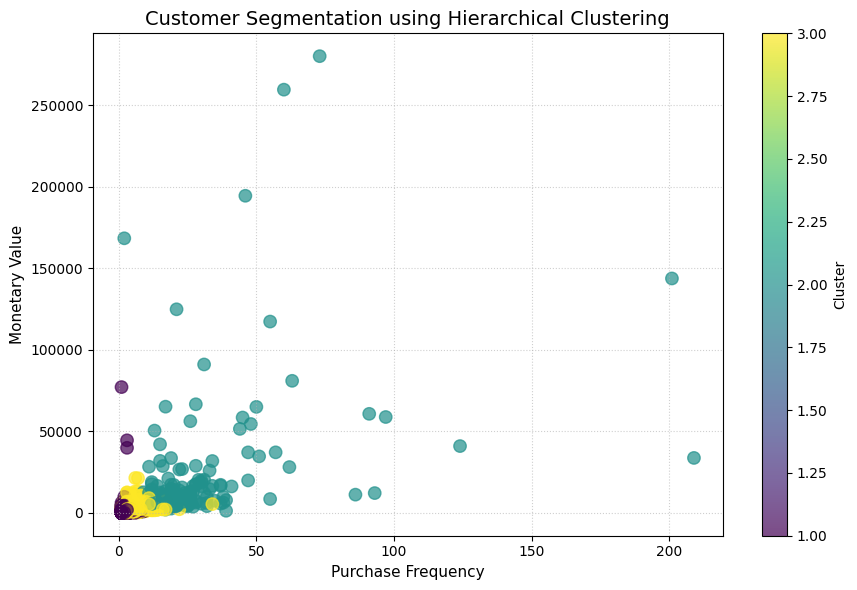

In [25]:
cluster_profile = rfm.groupby('Cluster').agg({
      'Recency': 'mean',
          'Frequency': 'mean',
              'Monetary': 'mean',
                  'Cluster': 'count'
                  }).round(2)


                  # Rename Cluster count
cluster_profile = cluster_profile.rename(
    columns={
        'Cluster': 'Number of Customers'
        }
    )


print("\n================ CLUSTER PROFILE ================")

print(cluster_profile)


                                  # ------------------------------------------------------------
                                  # 15. Number of customers in each cluster
                                  # ------------------------------------------------------------

print("\nNumber of customers in each cluster:")

print(rfm['Cluster'].value_counts().sort_index())


                                      # ------------------------------------------------------------
                                      # 16. Visualize clusters
                                      # ------------------------------------------------------------

plt.figure(figsize=(9, 6))

scatter = plt.scatter(rfm['Frequency'],rfm['Monetary'],c=rfm['Cluster'],s=80,alpha=0.7)

plt.title('Customer Segmentation using Hierarchical Clustering',fontsize=14)

plt.xlabel('Purchase Frequency',fontsize=11)

plt.ylabel('Monetary Value',fontsize=11)

plt.colorbar(scatter,label='Cluster')

plt.grid(linestyle=':',alpha=0.6)

plt.tight_layout()

plt.show()
